# Meteorological Feature Overlap Analysis

**Comprehensive Analysis of MCS, AR, and ETC Interactions**

This notebook implements a scientifically robust framework for analyzing overlaps between:
- **MCS (Mesoscale Convective Systems)**: Smallest scale features
- **AR (Atmospheric Rivers)**: Medium scale features  
- **ETC (Extratropical Cyclones)**: Largest scale features

## Key Features:
- **Meteorologically-informed thresholds** respecting atmospheric scale hierarchy
- **Pair-based filtering** ensuring visual consistency
- **Vectorized overlap detection** for efficiency
- **Comprehensive visualization** of 2-way and 3-way interactions

## Threshold Design:
- **2-way overlaps**: MCS=20%, AR=10%, ETC=5%
- **3-way overlaps**: MCS=20%, AR=10%, ETC=0% (environmental context)

In [1]:
# IMPORTS AND SETUP
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
import cartopy.crs as ccrs
import cartopy.feature as cf
import easygems.healpix as egh
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set figure parameters
plt.rcParams['figure.dpi'] = 144
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("✅ All libraries imported successfully")

✅ All libraries imported successfully


In [2]:
# LOAD DATA
# Update these paths as needed for your data location
# in_dir = '/global/cfs/cdirs/m1867/zfeng/PyFLEXTRKR/quicklook_dev/sample_data'
# root_dir = '/global/homes/f/feng045/program/hackathon/hk25-teams/hk25-Tracking'
# figdir = f'{root_dir}/figures'

source_name = "scream"
root_dir = "/pscratch/sd/w/wcmca1/hackathon/allmasks/"
in_dir = f"{root_dir}/{source_name}_allmasks_hp8_v1.zarr"

figdir = "/global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/"
# figdir = "/pscratch/sd/w/wcmca1/hackathon/"
os.makedirs(figdir, exist_ok=True)

# Load the processed dataset
print(f"Loading data from: {in_dir}")

ds = xr.open_dataset(in_dir)
ds = ds.pipe(egh.attach_coords)
ds

Loading data from: /pscratch/sd/w/wcmca1/hackathon/allmasks//scream_allmasks_hp8_v1.zarr


<xarray.Dataset> Size: 49GB
Dimensions:   (time: 3138, cell: 786432)
Coordinates:
  * time      (time) datetime64[ns] 25kB 2019-08-01T03:00:00 ... 2020-09-01
    crs       int64 8B 0
  * cell      (cell) int64 6MB 0 1 2 3 4 ... 786427 786428 786429 786430 786431
    lat       (cell) float64 6MB 0.1492 0.2984 0.2984 ... -0.2984 -0.1492
    lon       (cell) float64 6MB 45.0 45.18 44.82 45.0 ... 315.2 314.8 315.0
Data variables:
    ar_mask   (time, cell) int32 10GB ...
    etc_mask  (time, cell) int32 10GB ...
    mcs_mask  (time, cell) float64 20GB ...
    tc_mask   (time, cell) int32 10GB ...
Attributes: (12/37)
    Contact:                      Zhe Feng: zhe.feng@pnnl.gov
    Conventions:                  CF-1.8
    Created_on:                   Mon May  5 10:42:36 2025
    Institution:                  Pacific Northwest National Laboratory
    NCO:                          netCDF Operators version 5.3.2 (Homepage = ...
    Title:                        HEALPix remapped tracking mask data (zoom=8)
    ...                           ...
    tb_threshold_core:            225.0
    tb_threshold_environment:     261.0
    tb_threshold_warmanvil:       261.0
    topography_file:              /lustre/orion/cli115/world-shared/e3sm/inpu...
    username:                     noel
    zoom:                         8

In [21]:
# tm = '2019-11-24T03'
tm = '2019-11-26T06'

# Select single time step first
_ds = ds.sel(time=tm, method='nearest')

print(f"Dataset loaded successfully!")
print(f"Data variables: {list(_ds.data_vars)}")
print(f"Spatial dimensions: {_ds.dims}")

# Display basic statistics
n_mcs = len(np.unique(_ds.mcs_mask.values[_ds.mcs_mask.values > 0]))
n_ar = len(np.unique(_ds.ar_mask.values[_ds.ar_mask.values > 0]))
n_etc = len(np.unique(_ds.etc_mask.values[_ds.etc_mask.values > 0]))

print(f"\nFeature counts:")
print(f"  MCS tracks: {n_mcs}")
print(f"  AR tracks: {n_ar}")
print(f"  ETC tracks: {n_etc}")

Dataset loaded successfully!
Data variables: ['ar_mask', 'etc_mask', 'mcs_mask', 'tc_mask']
Spatial dimensions: FrozenMappingWarningOnValuesAccess({'cell': 786432})

Feature counts:
  MCS tracks: 108
  AR tracks: 8
  ETC tracks: 8


## Visualize all masks

In [42]:
def plot_all_feature_masks(ds, title="", figsize=(12, 6), colors=None, figname=None, dpi=200, 
                          alphas=None, title_fontsize=14, legend_fontsize=12, 
                          show_track_labels=True, track_fontsize=8):
    """
    Plot all 4 feature masks at a single time step with optional track labels.
    
    Parameters:
    - ds: xarray Dataset containing the mask variables (assumes single time step)
    - title: optional title for the plot
    - figsize: figure size tuple
    - colors: dict with color names for each feature type, e.g. {'mcs': 'lightskyblue', 'ar': 'orange', 'etc': 'lightgreen', 'tc': 'lightcoral'}
    - figname: if provided, save figure as PNG with this filename
    - dpi: DPI for figure display and saving (default 200)
    - alphas: dict with alpha values for each feature type, e.g. {'mcs': 0.6, 'ar': 0.7, 'etc': 0.5, 'tc': 0.8}
    - title_fontsize: font size for the plot title (default 14)
    - legend_fontsize: font size for the legend (default 12)
    - show_track_labels: whether to show track ID labels for ETC and AR features (default True)
    - track_fontsize: font size for track labels (default 8)
    
    Returns:
    - fig, ax: matplotlib figure and axes objects
    """
    # Set default colors
    if colors is None:
        colors = {
            'mcs': 'lightskyblue',
            'ar': 'orange', 
            'etc': 'lightgreen',
            'tc': 'lightcoral'
        }
    
    # Set default alphas
    if alphas is None:
        alphas = {
            'mcs': 0.6,
            'ar': 0.6,
            'etc': 0.6,
            'tc': 0.6
        }
    
    # Create base map (integrated from worldmap_base)
    projection = ccrs.Robinson(central_longitude=-135)
    fig, ax = plt.subplots(
        figsize=figsize,
        subplot_kw={"projection": projection},
        constrained_layout=True
    )
    fig.dpi = dpi
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    ax.add_feature(cf.BORDERS, linewidth=0.4)

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {"size": 10}
    gl.ylabel_style = {"size": 10}

    # Set title
    plot_title = title if title else "Feature Masks"
    ax.set_title(plot_title, fontsize=title_fontsize)
    
    # Extract masks (assuming single time step)
    mcs_mask = ds['mcs_mask'].squeeze()
    ar_mask = ds['ar_mask'].squeeze()
    etc_mask = ds['etc_mask'].squeeze()
    tc_mask = ds['tc_mask'].squeeze()
    
    # Convert masks to binary (all features = 1, no features = 0)
    mcs_binary = xr.where(mcs_mask > 0, 1, 0)
    ar_binary = xr.where(ar_mask > 0, 1, 0)
    etc_binary = xr.where(etc_mask > 0, 1, 0)
    tc_binary = xr.where(tc_mask > 0, 1, 0)
    
    # Plot MCS mask with customizable color and alpha
    if np.any(mcs_binary > 0):
        img_mcs = egh.healpix_show(
            mcs_binary.where(mcs_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['mcs']]), 
            alpha=alphas['mcs'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot AR mask with customizable color and alpha
    if np.any(ar_binary > 0):
        img_ar = egh.healpix_show(
            ar_binary.where(ar_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['ar']]), 
            alpha=alphas['ar'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot ETC mask with customizable color and alpha
    if np.any(etc_binary > 0):
        img_etc = egh.healpix_show(
            etc_binary.where(etc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['etc']]), 
            alpha=alphas['etc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Plot TC mask with customizable color and alpha
    if np.any(tc_binary > 0):
        img_tc = egh.healpix_show(
            tc_binary.where(tc_binary > 0), 
            ax=ax, 
            cmap=mpl.colors.ListedColormap([colors['tc']]), 
            alpha=alphas['tc'],
            vmin=0.5, 
            vmax=1.5
        )
    
    # Add track labels for ETC and AR features if requested
    if show_track_labels:
        # Helper function for circular longitude averaging (handles dateline crossing)
        def circular_lon_mean(lon_values):
            """Calculate circular mean for longitude values to handle dateline crossing."""
            # Convert to radians
            lon_rad = np.deg2rad(lon_values)
            # Calculate circular mean using complex numbers
            mean_complex = np.mean(np.exp(1j * lon_rad))
            # Convert back to degrees and ensure 0-360 range
            mean_lon = np.rad2deg(np.angle(mean_complex))
            if mean_lon < 0:
                mean_lon += 360
            return mean_lon
        
        # Add ETC track labels (green)
        etc_tracks = np.unique(etc_mask.values[etc_mask.values > 0])
        for track_id in etc_tracks:
            track_pixels = (etc_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='green', ha='center', va='center')
        
        # Add AR track labels (darkorange)
        ar_tracks = np.unique(ar_mask.values[ar_mask.values > 0])
        for track_id in ar_tracks:
            track_pixels = (ar_mask == track_id)
            if track_pixels.any():
                # Calculate average lat/lon for this track using circular statistics for longitude
                lon_values = ds.lon.where(track_pixels).values
                lat_values = ds.lat.where(track_pixels).values
                
                # Remove NaN values
                valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
                if np.any(valid_mask):
                    lon_clean = lon_values[valid_mask]
                    lat_clean = lat_values[valid_mask]
                    
                    avg_lon = circular_lon_mean(lon_clean)
                    avg_lat = np.mean(lat_clean)
                    
                    ax.text(avg_lon, avg_lat, str(int(track_id)), 
                           transform=ccrs.PlateCarree(),
                           fontsize=track_fontsize, fontweight='bold', 
                           color='darkorange', ha='center', va='center')
    
    # Add legend
    legend_elements = [
        Patch(facecolor=colors['mcs'], alpha=alphas['mcs'], label='MCS'),
        Patch(facecolor=colors['ar'], alpha=alphas['ar'], label='AR'),
        Patch(facecolor=colors['etc'], alpha=alphas['etc'], label='ETC'),
        Patch(facecolor=colors['tc'], alpha=alphas['tc'], label='TC')
    ]
    fig.legend(handles=legend_elements, bbox_to_anchor=(0.99, 0.99), loc='upper right', bbox_transform=fig.transFigure,
               fontsize=legend_fontsize, framealpha=0.9, fancybox=True, shadow=True)
    
    # Save figure if filename provided
    if figname is not None:
        plt.savefig(figname, dpi=dpi, bbox_inches='tight')
        print(f"Figure saved as {figname}")
    
    return fig, ax

Figure saved as /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_allmasks_20191126_0600.png


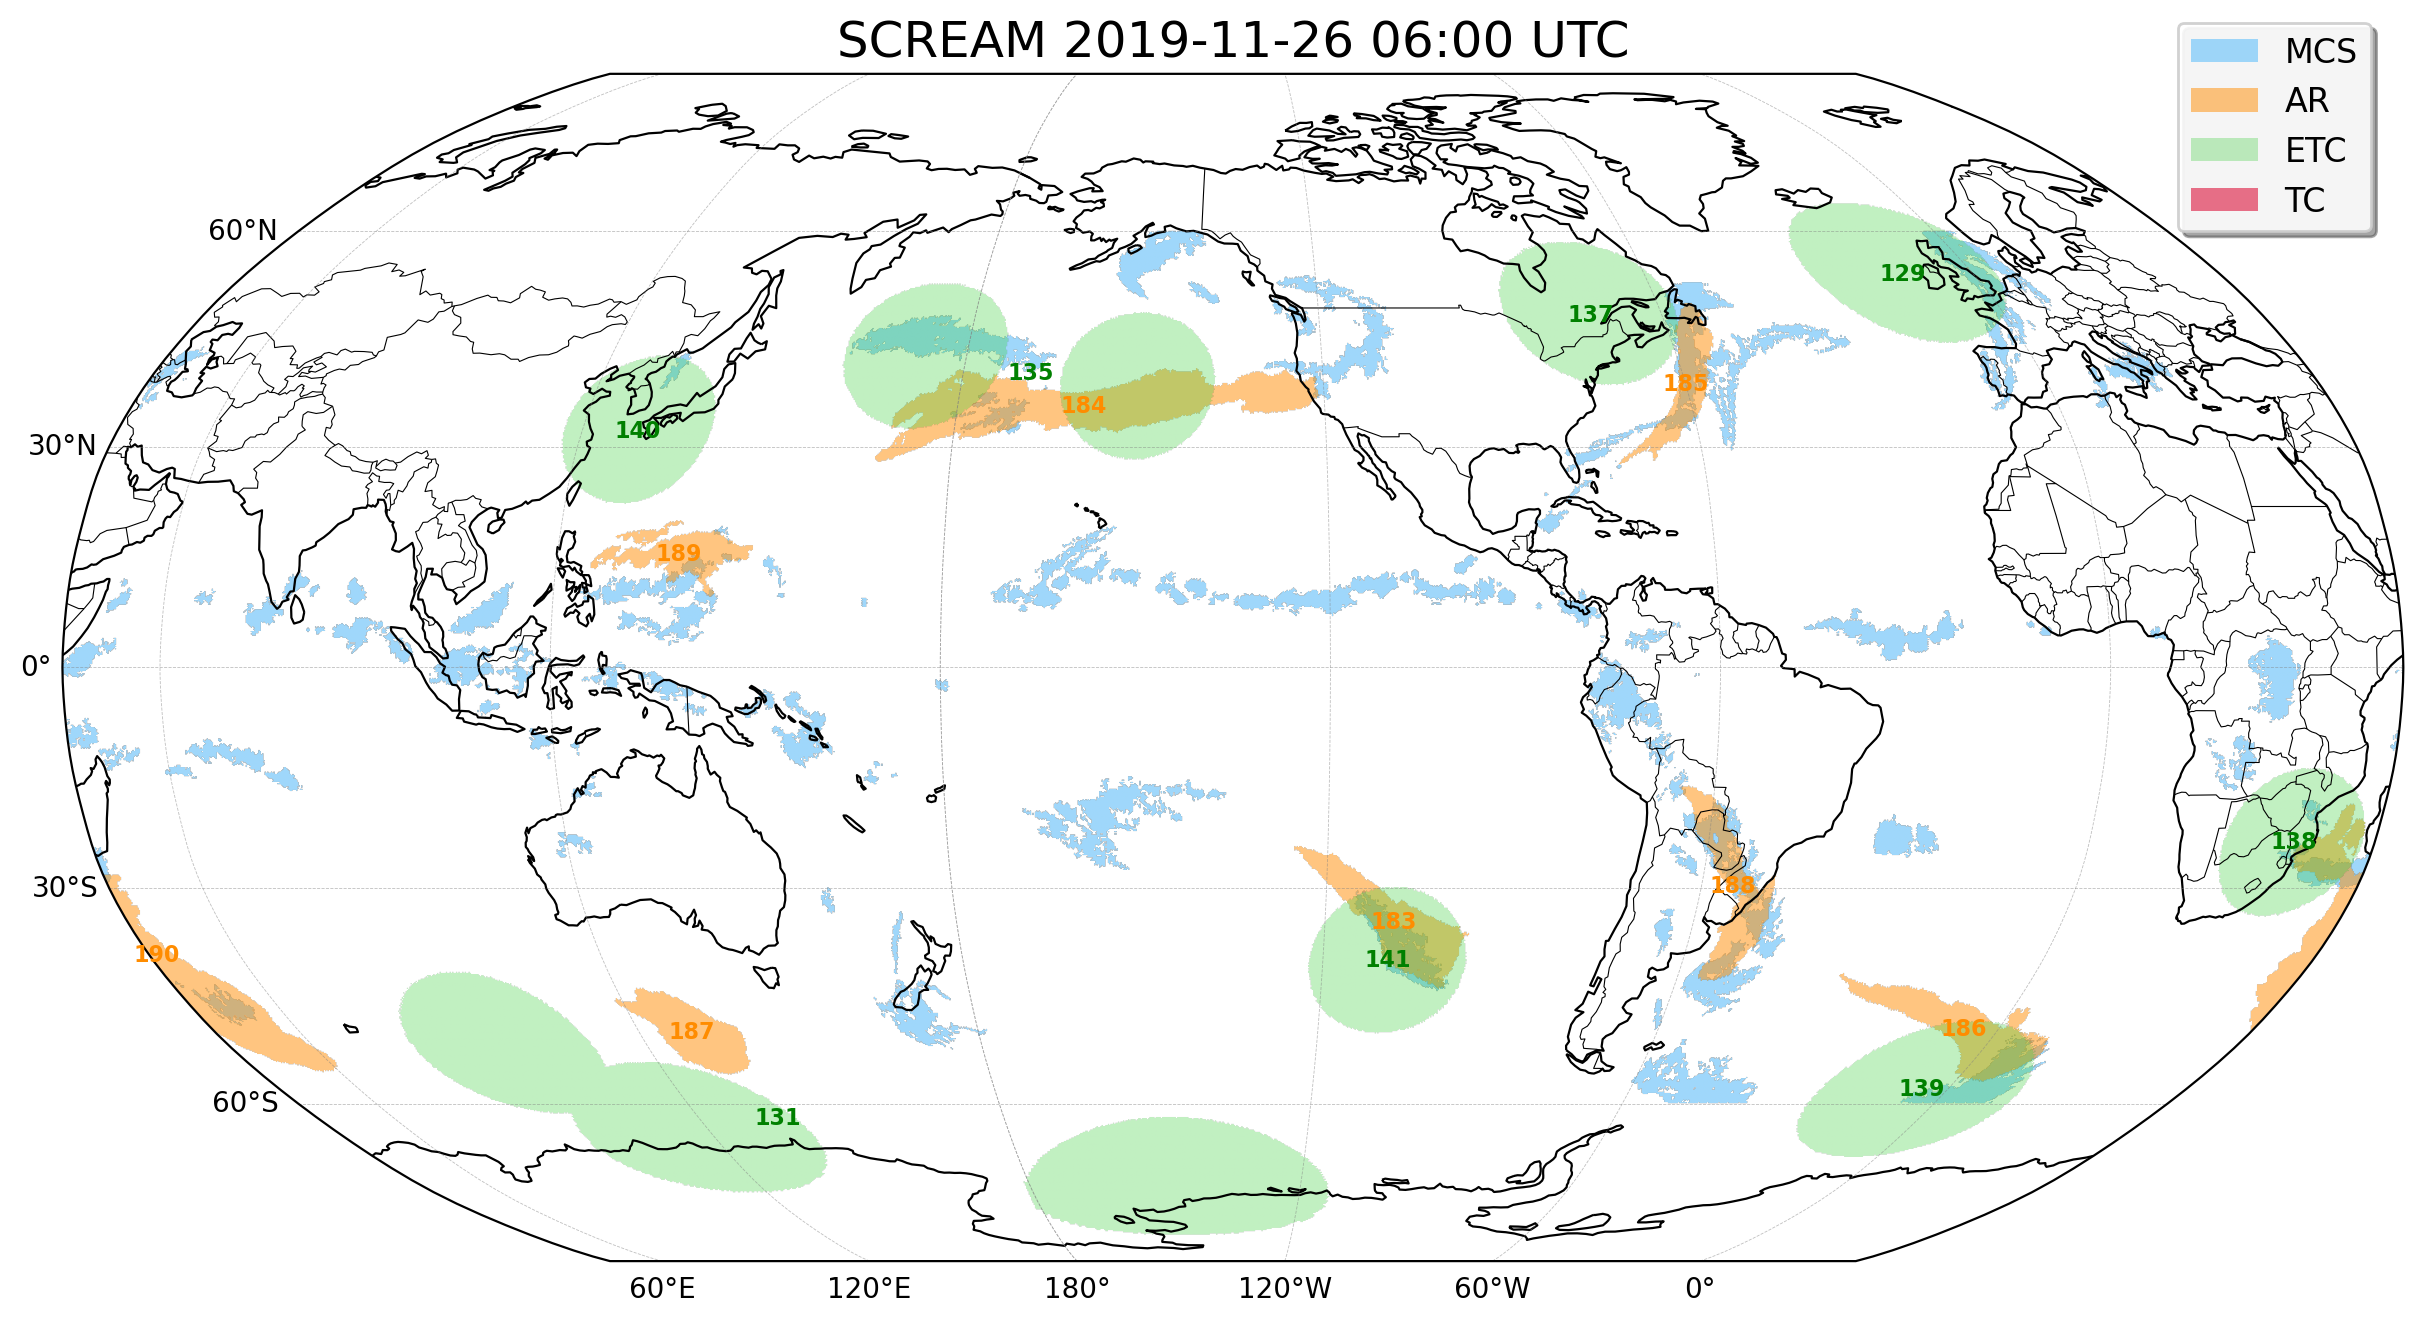

In [43]:
_time = ds.time.sel(time=tm, method='nearest')
time_label = _time.dt.strftime('%Y-%m-%d %H:%M UTC').item()
time_str = _time.dt.strftime('%Y%m%d_%H%M').item()
title_with_time = f"{source_name.upper()} {time_label}"
figname = f'{figdir}{source_name}_allmasks_{time_str}.png'

# Example with custom colors and figure saving
custom_colors = {
    'mcs': 'lightskyblue',
    'ar': 'darkorange', 
    'etc': 'limegreen',
    'tc': 'crimson'
}
# Example with custom alphas and font sizes
custom_alphas = {
    'mcs': 0.8,    # More opaque for MCS
    'ar': 0.5,     # More transparent for AR
    'etc': 0.3,    # Medium transparency for ETC
    'tc': 0.6      # Very opaque for TC
}
title_fontsize = 18
legend_fontsize = 12

fig, ax = plot_all_feature_masks(
    _ds, 
    title=title_with_time, 
    figsize=(12, 6.75),
    colors=custom_colors,
    alphas=custom_alphas,
    title_fontsize=title_fontsize,
    legend_fontsize=legend_fontsize,
    figname=figname,
    dpi=200,
    show_track_labels=True,
    track_fontsize=8
)
plt.show()

<Figure size 921.6x691.2 with 0 Axes>

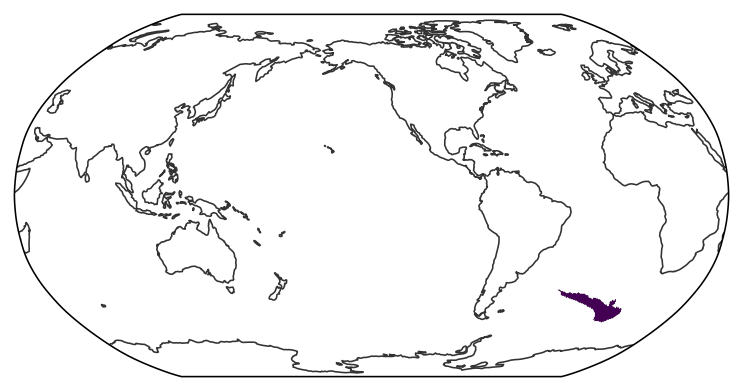

In [41]:
ar_186 = _ds.ar_mask.where(_ds.ar_mask == 186)
egh.healpix_show(ar_186.where(ar_186 > 0))
# np.count_nonzero(_ds.ar_mask == 186)

## Core Analysis Functions

These functions implement the improved overlap detection algorithms with meteorological awareness.

In [44]:
def find_overlapping_tracks(track_mask, binary_sum_mask, min_overlap_fraction=0.2, 
                           overlap_threshold=1, verbose=True):
    """
    Find tracks that have significant overlap with other meteorological features.
    
    This function implements efficient vectorized overlap detection using binary
    summation masks and configurable thresholds for different overlap scenarios.
    
    Parameters:
    -----------
    track_mask : xarray.DataArray
        Mask array where each unique positive value represents a track ID
    binary_sum_mask : xarray.DataArray
        Binary summation mask where values indicate number of overlapping features:
        - 1: single feature present
        - 2: two features overlap (2-way)
        - 3: three features overlap (3-way)
    min_overlap_fraction : float, default=0.2
        Minimum fraction of track pixels that must overlap to be considered significant
    overlap_threshold : int, default=1
        Minimum value in binary_sum_mask to be considered overlap:
        - 1: any overlap (including single features)
        - 2: only 2-way and 3-way overlaps
        - 3: only 3-way overlaps
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Analysis results containing:
        - 'tracks_exceeding_threshold': numpy array of track IDs meeting criteria
        - 'overlap_fractions': dict mapping track ID to overlap fraction
        - 'total_tracks_analyzed': total number of unique tracks
        - 'threshold_info': dict with analysis parameters
    
    Examples:
    ---------
    # Find MCS tracks with 20% AR overlap (2-way or 3-way)
    results = find_overlapping_tracks(mcs_mask, mcs_ar_sum, 
                                     min_overlap_fraction=0.2, overlap_threshold=2)
    
    # Find ETC tracks in 3-way overlaps only
    results = find_overlapping_tracks(etc_mask, mcs_ar_etc_sum,
                                     min_overlap_fraction=0.0, overlap_threshold=3)
    """
    if verbose:
        print(f"Analyzing overlaps with threshold >= {overlap_threshold}, min_fraction = {min_overlap_fraction}")
    
    # Get all unique track IDs (excluding 0 which represents no track)
    unique_tracks = np.unique(track_mask.values[track_mask.values > 0])
    
    tracks_exceeding_threshold = []
    overlap_fractions = {}
    
    # Vectorized analysis for each track
    for track_id in unique_tracks:
        # Get pixels belonging to this track
        track_pixels = (track_mask == track_id)
        
        # Count total pixels for this track
        total_pixels = track_pixels.sum().compute().item()
        
        if total_pixels == 0:
            continue
            
        # Find overlap pixels (where binary sum meets threshold)
        overlap_pixels = track_pixels & (binary_sum_mask > overlap_threshold)
        overlap_count = overlap_pixels.sum().compute().item()
        
        # Calculate overlap fraction
        overlap_fraction = overlap_count / total_pixels
        overlap_fractions[track_id] = overlap_fraction
        
        # Check if this track meets the threshold
        if overlap_fraction >= min_overlap_fraction:
            tracks_exceeding_threshold.append(track_id)
    
    tracks_exceeding_threshold = np.array(tracks_exceeding_threshold)
    
    if verbose:
        print(f"Found {len(tracks_exceeding_threshold)} tracks out of {len(unique_tracks)} total")
        if len(tracks_exceeding_threshold) > 0:
            print(f"Track IDs: {tracks_exceeding_threshold}")
    
    return {
        'tracks_exceeding_threshold': tracks_exceeding_threshold,
        'overlap_fractions': overlap_fractions,
        'total_tracks_analyzed': len(unique_tracks),
        'threshold_info': {
            'min_overlap_fraction': min_overlap_fraction,
            'overlap_threshold': overlap_threshold,
            'tracks_meeting_criteria': len(tracks_exceeding_threshold)
        }
    }

print("✅ find_overlapping_tracks() function defined")

✅ find_overlapping_tracks() function defined


In [45]:
def find_overlap_pairs(mask1, mask2, binary_sum_mask, 
                      thresh1=0.2, thresh2=0.1, overlap_threshold=2,
                      feature1_name="Feature1", feature2_name="Feature2", verbose=True):
    """
    Find valid pairs of overlapping tracks between two feature types.
    
    This function implements pair-based filtering to ensure that only tracks
    with mutual spatial overlap are identified, preventing orphaned track
    visualization issues.
    
    Parameters:
    -----------
    mask1, mask2 : xarray.DataArray
        Track masks for the two feature types to analyze
    binary_sum_mask : xarray.DataArray
        Binary summation mask indicating overlap regions
    thresh1, thresh2 : float
        Minimum overlap fractions for each feature type
    overlap_threshold : int, default=2
        Minimum value in binary_sum_mask for overlap detection
    feature1_name, feature2_name : str
        Names of the feature types for reporting
    verbose : bool, default=True
        Whether to print progress information
        
    Returns:
    --------
    dict : Results containing:
        - 'valid_pairs': list of (track1_id, track2_id) tuples
        - 'feature1_tracks': numpy array of feature1 track IDs in valid pairs
        - 'feature2_tracks': numpy array of feature2 track IDs in valid pairs
        - 'pair_details': detailed information about each pair
    
    Examples:
    ---------
    # Find MCS-AR pairs with bidirectional overlap verification
    pairs = find_overlap_pairs(mcs_mask, ar_mask, mcs_ar_sum,
                              thresh1=0.2, thresh2=0.1,
                              feature1_name="MCS", feature2_name="AR")
    """
    if verbose:
        print(f"Finding {feature1_name}-{feature2_name} pairs with thresholds: {thresh1:.1%}, {thresh2:.1%}")
    
    # Find overlapping tracks for each feature type
    feature1_results = find_overlapping_tracks(mask1, binary_sum_mask, 
                                              thresh1, overlap_threshold, verbose=False)
    feature2_results = find_overlapping_tracks(mask2, binary_sum_mask, 
                                              thresh2, overlap_threshold, verbose=False)
    
    feature1_tracks = feature1_results['tracks_exceeding_threshold']
    feature2_tracks = feature2_results['tracks_exceeding_threshold']
    
    # Find valid pairs through spatial overlap verification
    valid_pairs = []
    pair_details = {}
    
    for track1 in feature1_tracks:
        # Get pixels for this feature1 track
        track1_pixels = (mask1 == track1)
        
        # Find overlap region for this track
        track1_overlap_region = track1_pixels & (binary_sum_mask > overlap_threshold)
        
        # Check which feature2 tracks overlap spatially
        for track2 in feature2_tracks:
            track2_pixels = (mask2 == track2)
            
            # Check if these tracks have spatial co-occurrence
            spatial_overlap = track1_overlap_region & track2_pixels
            overlap_pixel_count = spatial_overlap.sum().compute().item()
            
            if overlap_pixel_count > 0:
                valid_pairs.append((track1, track2))
                pair_details[(track1, track2)] = {
                    'overlap_pixels': overlap_pixel_count,
                    'track1_fraction': feature1_results['overlap_fractions'][track1],
                    'track2_fraction': feature2_results['overlap_fractions'][track2]
                }
    
    # Extract unique track lists from valid pairs
    if valid_pairs:
        paired_feature1_tracks = np.unique([pair[0] for pair in valid_pairs])
        paired_feature2_tracks = np.unique([pair[1] for pair in valid_pairs])
    else:
        paired_feature1_tracks = np.array([])
        paired_feature2_tracks = np.array([])
    
    if verbose:
        print(f"Found {len(valid_pairs)} valid pairs:")
        print(f"  {feature1_name} tracks in pairs: {len(paired_feature1_tracks)}")
        print(f"  {feature2_name} tracks in pairs: {len(paired_feature2_tracks)}")
        if len(valid_pairs) > 0 and len(valid_pairs) <= 10:
            print(f"  Pairs: {valid_pairs}")
    
    return {
        'valid_pairs': valid_pairs,
        'feature1_tracks': paired_feature1_tracks,
        'feature2_tracks': paired_feature2_tracks,
        'pair_details': pair_details
    }

print("✅ find_overlap_pairs() function defined")

✅ find_overlap_pairs() function defined


## Binary Mask Creation

Create binary masks and summation masks for overlap detection.

In [46]:
# CREATE BINARY MASKS FOR OVERLAP ANALYSIS
print("Creating binary masks for overlap analysis...")

# Create binary masks (1 where feature exists, 0 elsewhere)
mcs_binary = xr.where(_ds.mcs_mask > 0, 1, 0)
ar_binary = xr.where(_ds.ar_mask > 0, 1, 0)
etc_binary = xr.where(_ds.etc_mask > 0, 1, 0)

# Create pairwise summation masks
mcs_ar_sum = mcs_binary + ar_binary
ar_etc_sum = ar_binary + etc_binary  
mcs_etc_sum = mcs_binary + etc_binary

# Create 3-way summation mask
mcs_ar_etc_sum = mcs_binary + ar_binary + etc_binary

print("✅ Binary masks created successfully")

# Display overlap statistics
print(f"\nOverlap region statistics:")
print(f"  MCS-AR 2-way overlaps: {(mcs_ar_sum == 2).sum().compute().item()} pixels")
print(f"  AR-ETC 2-way overlaps: {(ar_etc_sum == 2).sum().compute().item()} pixels")
print(f"  MCS-ETC 2-way overlaps: {(mcs_etc_sum == 2).sum().compute().item()} pixels")
print(f"  3-way overlaps: {(mcs_ar_etc_sum == 3).sum().compute().item()} pixels")

Creating binary masks for overlap analysis...
✅ Binary masks created successfully

Overlap region statistics:
  MCS-AR 2-way overlaps: 4629 pixels
  AR-ETC 2-way overlaps: 7228 pixels
  MCS-ETC 2-way overlaps: 4559 pixels
  3-way overlaps: 1581 pixels


## Meteorologically-Informed Overlap Analysis

Apply the improved thresholds that respect atmospheric scale hierarchy.

In [47]:
# METEOROLOGICALLY-INFORMED OVERLAP ANALYSIS
print("Performing meteorologically-informed overlap analysis...")
print("="*60)

# Define thresholds based on atmospheric scale hierarchy
mcs_thresh = 0.20  # 20% - smallest features, need substantial overlap
ar_thresh = 0.10   # 10% - medium features
etc_thresh_2way = 0.05  # 5% - largest features for 2-way overlaps
etc_thresh_3way = 0.00  # 0% - environmental context for 3-way overlaps

print(f"Overlap thresholds:")
print(f"  MCS: {mcs_thresh:.0%} (all scenarios)")
print(f"  AR: {ar_thresh:.0%} (all scenarios)")
print(f"  ETC: {etc_thresh_2way:.0%} (2-way), {etc_thresh_3way:.0%} (3-way)")

# 1. 3-WAY OVERLAPS
print(f"\n1. 3-WAY OVERLAPS:")
print("-" * 20)

# Create 3-way overlap mask (only where all 3 features overlap)
threeway_overlap_mask = (mcs_ar_etc_sum == 3).astype(int)
print(f"True 3-way overlap pixels: {threeway_overlap_mask.sum().compute().item()}")

# Find tracks that participate in 3-way overlaps
mcs_ar_etc_results = find_overlapping_tracks(_ds.mcs_mask, threeway_overlap_mask, 
                                            mcs_thresh, overlap_threshold=0)
ar_mcs_etc_results = find_overlapping_tracks(_ds.ar_mask, threeway_overlap_mask, 
                                            ar_thresh, overlap_threshold=0)
etc_mcs_ar_results = find_overlapping_tracks(_ds.etc_mask, threeway_overlap_mask, 
                                            etc_thresh_3way, overlap_threshold=0)

# Extract tracks that ACTUALLY exceed thresholds (not just all tracks with overlap)
mcs_tracks_with_ar_etc_overlap = []
for track_id, fraction in mcs_ar_etc_results['overlap_fractions'].items():
    if fraction >= mcs_thresh:
        mcs_tracks_with_ar_etc_overlap.append(track_id)
mcs_tracks_with_ar_etc_overlap = np.array(mcs_tracks_with_ar_etc_overlap)

ar_tracks_with_mcs_etc_overlap = []
for track_id, fraction in ar_mcs_etc_results['overlap_fractions'].items():
    if fraction >= ar_thresh:
        ar_tracks_with_mcs_etc_overlap.append(track_id)
ar_tracks_with_mcs_etc_overlap = np.array(ar_tracks_with_mcs_etc_overlap)

etc_tracks_with_mcs_ar_overlap = []
for track_id, fraction in etc_mcs_ar_results['overlap_fractions'].items():
    if fraction > etc_thresh_3way:  # Use > 0 instead of >= 0 to exclude zero overlaps
        etc_tracks_with_mcs_ar_overlap.append(track_id)
etc_tracks_with_mcs_ar_overlap = np.array(etc_tracks_with_mcs_ar_overlap)

print(f"\n3-way overlap results:")
print(f"  MCS tracks: {len(mcs_tracks_with_ar_etc_overlap)}")
print(f"  AR tracks: {len(ar_tracks_with_mcs_etc_overlap)}")
print(f"  ETC tracks: {len(etc_tracks_with_mcs_ar_overlap)}")

# 2. 2-WAY PAIRS WITH EXCLUSION OF 3-WAY PARTICIPANTS
print(f"\n2. 2-WAY PAIRS (excluding 3-way participants):")
print("-" * 45)

# Find all potential 2-way overlaps
mcs_ar_pairs_all = find_overlap_pairs(_ds.mcs_mask, _ds.ar_mask, mcs_ar_sum,
                                     mcs_thresh, ar_thresh, overlap_threshold=0,
                                     feature1_name="MCS", feature2_name="AR")

ar_etc_pairs_all = find_overlap_pairs(_ds.ar_mask, _ds.etc_mask, ar_etc_sum,
                                     ar_thresh, etc_thresh_2way, overlap_threshold=0,
                                     feature1_name="AR", feature2_name="ETC")

mcs_etc_pairs_all = find_overlap_pairs(_ds.mcs_mask, _ds.etc_mask, mcs_etc_sum,
                                      mcs_thresh, etc_thresh_2way, overlap_threshold=0,
                                      feature1_name="MCS", feature2_name="ETC")

# Filter out tracks that ACTUALLY EXCEED 3-way thresholds (not just participate)
mcs_ar_pairs_2way_only = [pair for pair in mcs_ar_pairs_all['valid_pairs']
                         if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                         and pair[1] not in ar_tracks_with_mcs_etc_overlap]

ar_etc_pairs_2way_only = [pair for pair in ar_etc_pairs_all['valid_pairs']
                         if pair[0] not in ar_tracks_with_mcs_etc_overlap 
                         and pair[1] not in etc_tracks_with_mcs_ar_overlap]

mcs_etc_pairs_2way_only = [pair for pair in mcs_etc_pairs_all['valid_pairs']
                          if pair[0] not in mcs_tracks_with_ar_etc_overlap 
                          and pair[1] not in etc_tracks_with_mcs_ar_overlap]

print(f"\n2-way pair results (excluding 3-way participants):")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")

# Debug output to check specific tracks
print(f"\nDebug - Tracks that ACTUALLY exceed 3-way thresholds:")
print(f"  MCS (>= {mcs_thresh*100}%): {mcs_tracks_with_ar_etc_overlap}")
print(f"  AR (>= {ar_thresh*100}%): {ar_tracks_with_mcs_etc_overlap}")
print(f"  ETC (> {etc_thresh_3way*100}%): {etc_tracks_with_mcs_ar_overlap}")

print(f"\n✅ Meteorologically-informed overlap analysis complete!")

Performing meteorologically-informed overlap analysis...
Overlap thresholds:
  MCS: 20% (all scenarios)
  AR: 10% (all scenarios)
  ETC: 5% (2-way), 0% (3-way)

1. 3-WAY OVERLAPS:
--------------------
True 3-way overlap pixels: 1581
Analyzing overlaps with threshold >= 0, min_fraction = 0.2
Found 5 tracks out of 108 total
Track IDs: [15960. 15980. 16277. 16294. 16312.]
Analyzing overlaps with threshold >= 0, min_fraction = 0.1
Found 2 tracks out of 8 total
Track IDs: [183 186]
Analyzing overlaps with threshold >= 0, min_fraction = 0.0
Found 8 tracks out of 8 total
Track IDs: [129 131 135 137 138 139 140 141]

3-way overlap results:
  MCS tracks: 5
  AR tracks: 2
  ETC tracks: 5

2. 2-WAY PAIRS (excluding 3-way participants):
---------------------------------------------
Finding MCS-AR pairs with thresholds: 20.0%, 10.0%
Found 5 tracks out of 108 total
Track IDs: [15960. 15980. 16277. 16294. 16312.]
Analyzing overlaps with threshold >= 0, min_fraction = 0.1
Found 2 tracks out of 8 total

In [48]:
# EXTRACT TRACK LISTS FOR VISUALIZATION AND CHECK RESULTS
print("Extracting track lists for visualization...")

# Extract track lists from 2-way-only pairs for visualization
if mcs_ar_pairs_2way_only:
    mcs_tracks_paired_2way_only = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired_2way_only = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired_2way_only = np.array([])
    ar_tracks_paired_2way_only = np.array([])

if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar_2way_only = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_ar_2way_only = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc_2way_only = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs_2way_only = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc_2way_only = np.array([])
    etc_tracks_paired_with_mcs_2way_only = np.array([])

print(f"Track lists extracted for visualization:")
print(f"  MCS-AR pairs: {len(mcs_ar_pairs_2way_only)} pairs")
print(f"  AR-ETC pairs: {len(ar_etc_pairs_2way_only)} pairs")  
print(f"  MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)} pairs")
print(f"  3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC tracks")

# Check 3-way issue
etc_in_3way_all = np.unique(_ds.etc_mask.values[threeway_overlap_mask > 0])
etc_in_3way_all = etc_in_3way_all[etc_in_3way_all > 0]
print(f"  ✓ All ETC tracks in 3-way regions: {etc_in_3way_all}")
print(f"  ✓ ETC tracks that exceed 3-way threshold: {etc_tracks_with_mcs_ar_overlap}")

print(f"\n✅ Track extraction complete!")

Extracting track lists for visualization...
Track lists extracted for visualization:
  MCS-AR pairs: 15 pairs
  AR-ETC pairs: 0 pairs
  MCS-ETC pairs: 2 pairs
  3-way overlaps: 5 MCS, 2 AR, 5 ETC tracks
  ✓ All ETC tracks in 3-way regions: [135 137 138 139 141]
  ✓ ETC tracks that exceed 3-way threshold: [135 137 138 139 141]

✅ Track extraction complete!


In [49]:
ar_etc_pairs_2way_only

[]

In [50]:
mcs_etc_pairs_2way_only

[(np.float64(16142.0), np.int32(129)), (np.float64(16341.0), np.int32(140))]

## Create Visualization Masks

Generate the masks needed for the comprehensive 4-panel visualization.

In [51]:
# CREATE VISUALIZATION MASKS
print("Creating masks for comprehensive visualization...")

# Extract track lists from 2-way pairs for visualization
if ar_etc_pairs_2way_only:
    ar_tracks_paired_with_etc = np.unique([pair[0] for pair in ar_etc_pairs_2way_only])
    etc_tracks_paired_with_ar = np.unique([pair[1] for pair in ar_etc_pairs_2way_only])
else:
    ar_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_ar = np.array([])

if mcs_etc_pairs_2way_only:
    mcs_tracks_paired_with_etc = np.unique([pair[0] for pair in mcs_etc_pairs_2way_only])
    etc_tracks_paired_with_mcs = np.unique([pair[1] for pair in mcs_etc_pairs_2way_only])
else:
    mcs_tracks_paired_with_etc = np.array([])
    etc_tracks_paired_with_mcs = np.array([])

if mcs_ar_pairs_2way_only:
    mcs_tracks_paired = np.unique([pair[0] for pair in mcs_ar_pairs_2way_only])
    ar_tracks_paired = np.unique([pair[1] for pair in mcs_ar_pairs_2way_only])
else:
    mcs_tracks_paired = np.array([])
    ar_tracks_paired = np.array([])

# Create 2-way pair masks
mcs_ar_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired), 
    _ds.mcs_mask, 
    0
)
ar_mcs_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired), 
    _ds.ar_mask, 
    0
)

ar_etc_overlap_mask_pairs = xr.where(
    _ds.ar_mask.isin(ar_tracks_paired_with_etc), 
    _ds.ar_mask, 
    0
)
etc_ar_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_ar), 
    _ds.etc_mask, 
    0
)

mcs_etc_overlap_mask_pairs = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_paired_with_etc), 
    _ds.mcs_mask, 
    0
)
etc_mcs_overlap_mask_pairs = xr.where(
    _ds.etc_mask.isin(etc_tracks_paired_with_mcs), 
    _ds.etc_mask, 
    0
)

# Create 3-way overlap masks
mcs_ar_etc_overlap_mask = xr.where(
    _ds.mcs_mask.isin(mcs_tracks_with_ar_etc_overlap), 
    _ds.mcs_mask, 
    0
)
ar_mcs_etc_overlap_mask = xr.where(
    _ds.ar_mask.isin(ar_tracks_with_mcs_etc_overlap), 
    _ds.ar_mask, 
    0
)
etc_mcs_ar_overlap_mask = xr.where(
    _ds.etc_mask.isin(etc_tracks_with_mcs_ar_overlap), 
    _ds.etc_mask, 
    0
)

print("✅ All visualization masks created successfully!")

print(f"\nMask verification:")
print(f"  2-way masks created for {len(mcs_ar_pairs_2way_only) + len(ar_etc_pairs_2way_only) + len(mcs_etc_pairs_2way_only)} total pairs")
print(f"  3-way masks: {(etc_mcs_ar_overlap_mask > 0).sum().item()} ETC pixels")

Creating masks for comprehensive visualization...
✅ All visualization masks created successfully!

Mask verification:
  2-way masks created for 17 total pairs
  3-way masks: 35853 ETC pixels


## Comprehensive 4-Panel Visualization

Final visualization showing all meteorological feature interactions with improved analysis.

Creating comprehensive 4-panel visualization...
Figure saved as: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_cof_20191126_0600.png
Figure saved as: /global/cfs/cdirs/m1867/zfeng/hk25/quicklooks_test/scream_cof_20191126_0600.png


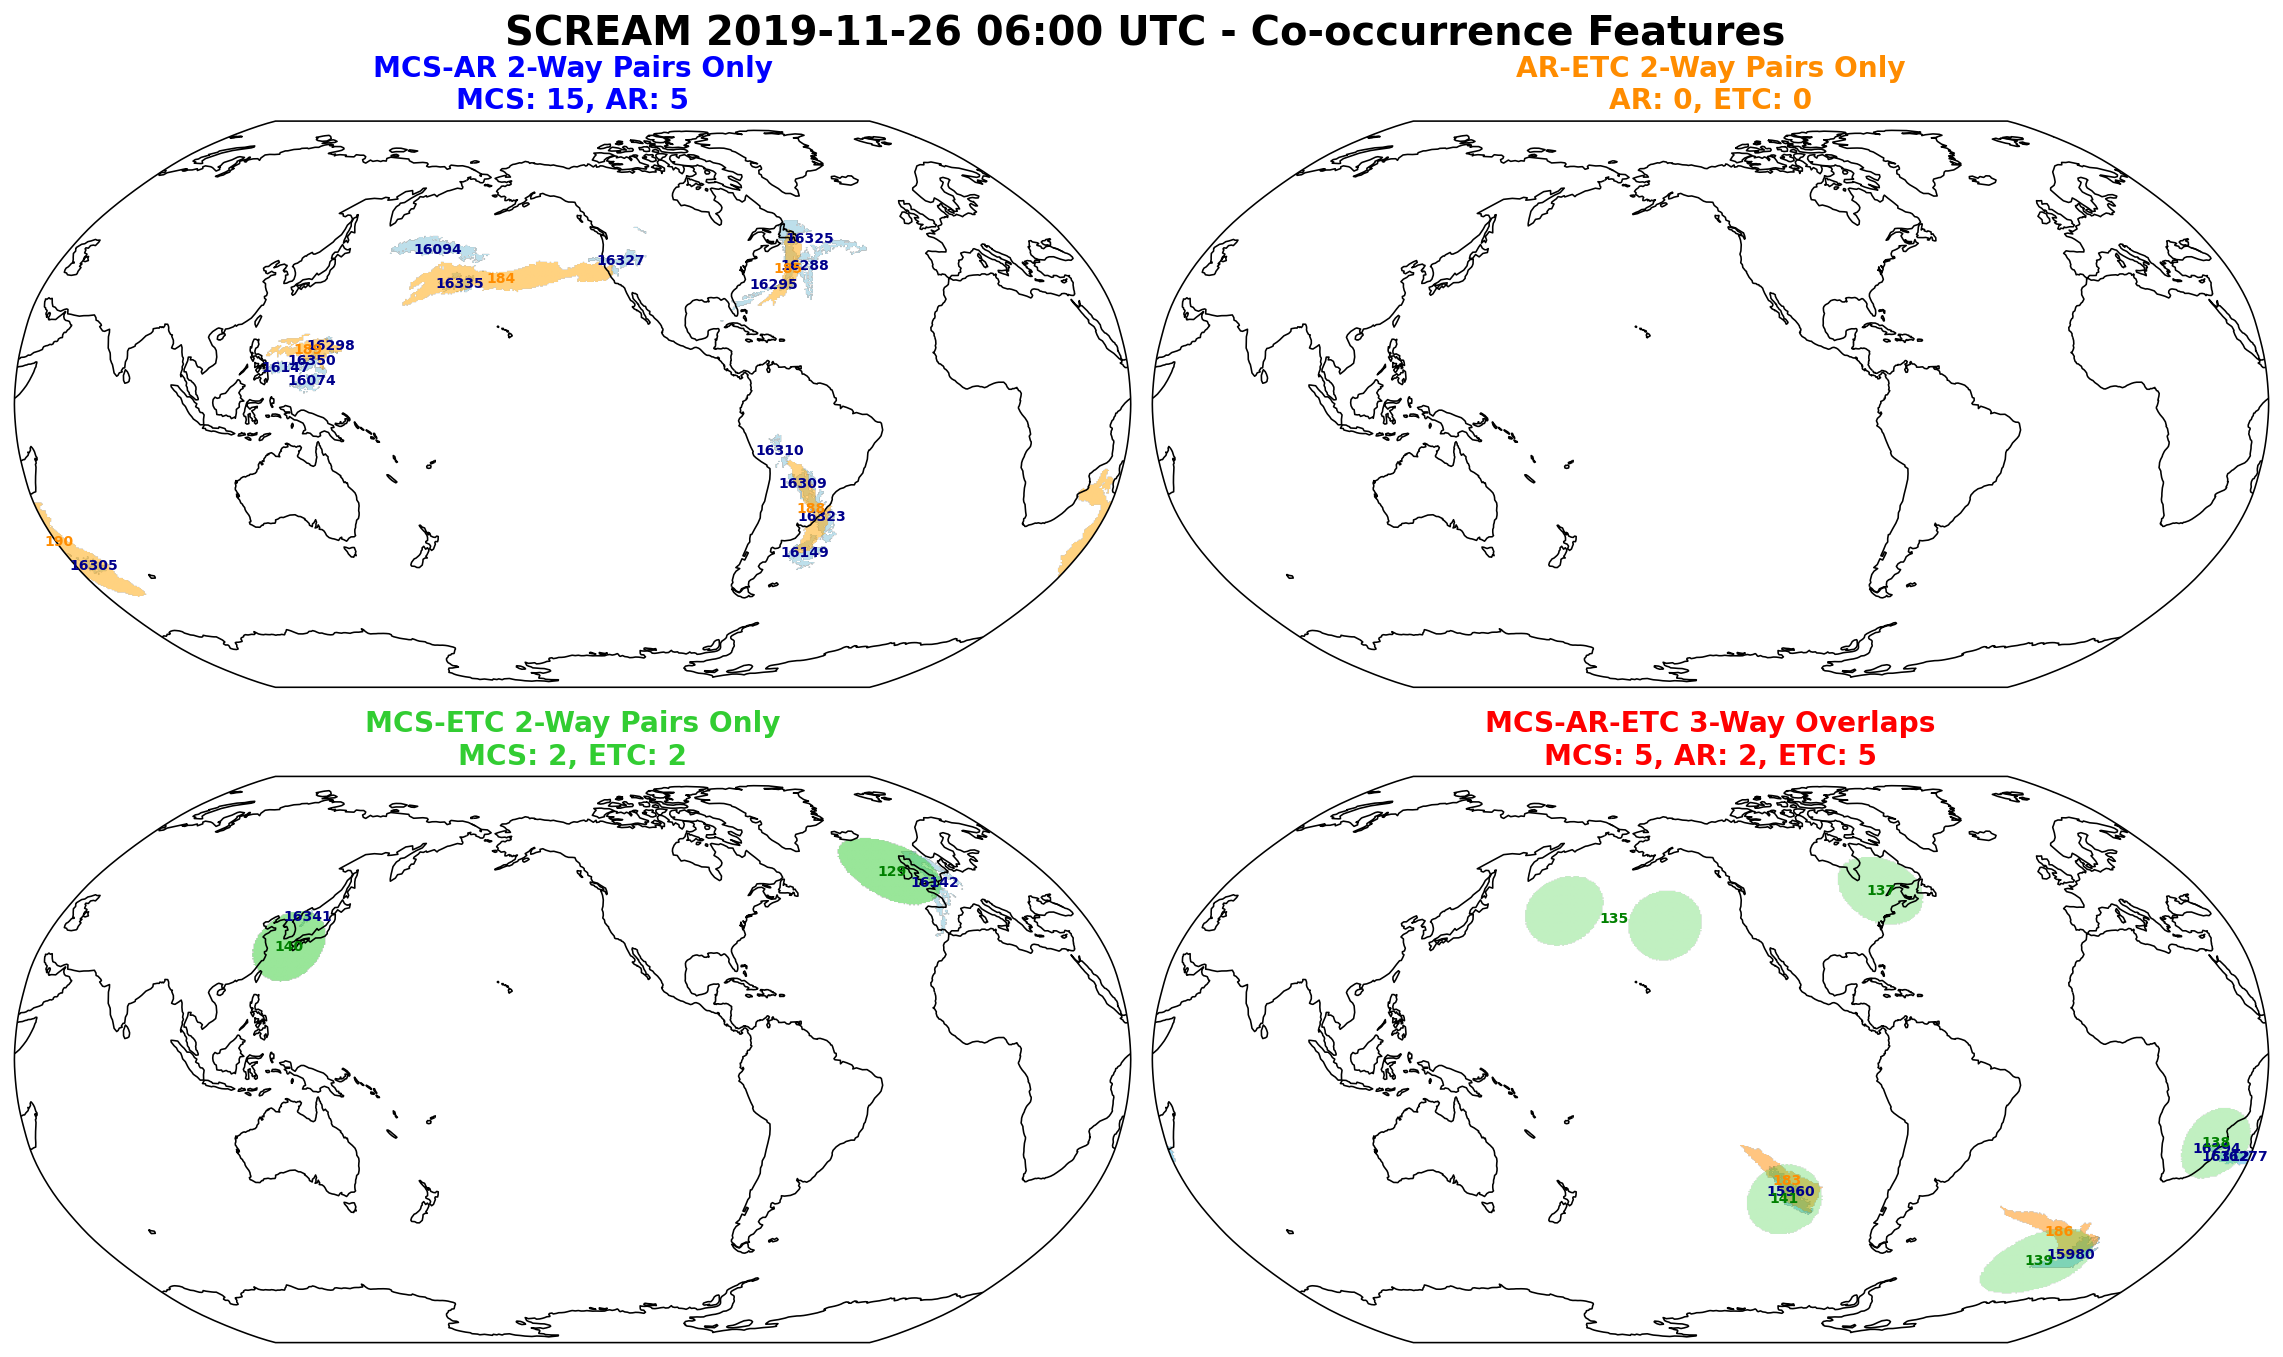


COMPREHENSIVE ANALYSIS SUMMARY:         
2-way MCS-AR pairs: 15
2-way AR-ETC pairs: 0
2-way MCS-ETC pairs: 2
3-way overlaps: 5 MCS, 2 AR, 5 ETC


In [52]:
# COMPREHENSIVE 4-PANEL VISUALIZATION WITH METEOROLOGICALLY-INFORMED ANALYSIS
print("Creating comprehensive 4-panel visualization...")

# Helper function for circular longitude averaging (handles dateline crossing)
def circular_lon_mean(lon_values):
    """Calculate circular mean for longitude values to handle dateline crossing."""
    # Convert to radians
    lon_rad = np.deg2rad(lon_values)
    # Calculate circular mean using complex numbers
    mean_complex = np.mean(np.exp(1j * lon_rad))
    # Convert back to degrees and ensure 0-360 range
    mean_lon = np.rad2deg(np.angle(mean_complex))
    if mean_lon < 0:
        mean_lon += 360
    return mean_lon

# Create datetime string for filename
datetime_string = time_str  # Already in YYYYMMDD_HHMM format

projection = ccrs.Robinson(central_longitude=-135)
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 10), 
                                             subplot_kw={"projection": projection})

# Add main title with source name and datetime
main_title = f"{source_name.upper()} {time_label} - Co-occurrence Features"
fig.suptitle(main_title, fontsize=20, fontweight='bold', y=0.97)

# Add coastlines and features to all axes
for ax in [ax1, ax2, ax3, ax4]:
    ax.set_global()
    ax.add_feature(cf.COASTLINE, linewidth=0.8)
    # ax.add_feature(cf.BORDERS, linewidth=0.4)

fontsize_tracks = 7
title_fontsize = 14

# Panel 1: MCS-AR 2-way pairs only
plt.sca(ax1)
if len(mcs_tracks_paired_2way_only) > 0:
    im_mcs_ar = egh.healpix_show(
        mcs_ar_overlap_mask_pairs.where(mcs_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax1)
if len(ar_tracks_paired_2way_only) > 0:
    im_ar_mcs = egh.healpix_show(
        ar_mcs_overlap_mask_pairs.where(ar_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.5, ax=ax1)

# Annotations for MCS-AR
for track_id in mcs_tracks_paired:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_paired:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax1.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

ax1.set_title(f"MCS-AR 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired)}, AR: {len(ar_tracks_paired)}", 
              fontsize=title_fontsize, fontweight='bold', color='blue')

# Panel 2: AR-ETC 2-way pairs only
plt.sca(ax2)
if len(ar_tracks_paired_with_etc_2way_only) > 0:
    im_ar_etc = egh.healpix_show(
        ar_etc_overlap_mask_pairs.where(ar_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('orange'), dpi=144, alpha=0.8, ax=ax2)
if len(etc_tracks_paired_with_ar_2way_only) > 0:
    im_etc_ar = egh.healpix_show(
        etc_ar_overlap_mask_pairs.where(etc_ar_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax2)

# Annotations for AR-ETC
for track_id in ar_tracks_paired_with_etc:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_paired_with_ar:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax2.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax2.set_title(f"AR-ETC 2-Way Pairs Only\nAR: {len(ar_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_ar)}", 
              fontsize=title_fontsize, fontweight='bold', color='darkorange')

# Panel 3: MCS-ETC 2-way pairs only
plt.sca(ax3)
if len(mcs_tracks_paired_with_etc_2way_only) > 0:
    im_mcs_etc = egh.healpix_show(
        mcs_etc_overlap_mask_pairs.where(mcs_etc_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('lightblue'), dpi=144, alpha=0.8, ax=ax3)
if len(etc_tracks_paired_with_mcs_2way_only) > 0:
    im_etc_mcs = egh.healpix_show(
        etc_mcs_overlap_mask_pairs.where(etc_mcs_overlap_mask_pairs > 0), 
        cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.5, ax=ax3)

# Annotations for MCS-ETC
for track_id in mcs_tracks_paired_with_etc:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in etc_tracks_paired_with_mcs:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax3.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax3.set_title(f"MCS-ETC 2-Way Pairs Only\nMCS: {len(mcs_tracks_paired_with_etc)}, ETC: {len(etc_tracks_paired_with_mcs)}", 
              fontsize=title_fontsize, fontweight='bold', color='limegreen')

# Panel 4: 3-way overlaps
plt.sca(ax4)
im_mcs_3way = egh.healpix_show(
    mcs_ar_etc_overlap_mask.where(mcs_ar_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('skyblue'), dpi=144, alpha=0.8, ax=ax4)
im_ar_3way = egh.healpix_show(
    ar_mcs_etc_overlap_mask.where(ar_mcs_etc_overlap_mask > 0), 
    cmap=mpl.colors.ListedColormap('darkorange'), dpi=144, alpha=0.5, ax=ax4)
im_etc_3way = egh.healpix_show(
    etc_mcs_ar_overlap_mask.where(etc_mcs_ar_overlap_mask > 0),
    cmap=mpl.colors.ListedColormap('limegreen'), dpi=144, alpha=0.3, ax=ax4)

# Annotations for 3-way overlaps
for track_id in mcs_tracks_with_ar_etc_overlap:
    track_pixels = _ds.mcs_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkblue', ha='center', va='center')

for track_id in ar_tracks_with_mcs_etc_overlap:
    track_pixels = _ds.ar_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='darkorange', ha='center', va='center')

for track_id in etc_tracks_with_mcs_ar_overlap:
    track_pixels = _ds.etc_mask == track_id
    if track_pixels.any():
        lon_values = _ds.lon.where(track_pixels).values
        lat_values = _ds.lat.where(track_pixels).values
        valid_mask = ~np.isnan(lon_values) & ~np.isnan(lat_values)
        if np.any(valid_mask):
            avg_lon = circular_lon_mean(lon_values[valid_mask])
            avg_lat = np.mean(lat_values[valid_mask])
            ax4.text(avg_lon, avg_lat, str(int(track_id)), transform=ccrs.PlateCarree(),
                    fontsize=fontsize_tracks, fontweight='bold', color='green', ha='center', va='center')

ax4.set_title(f"MCS-AR-ETC 3-Way Overlaps\nMCS: {len(mcs_tracks_with_ar_etc_overlap)}, AR: {len(ar_tracks_with_mcs_etc_overlap)}, ETC: {len(etc_tracks_with_mcs_ar_overlap)}", 
              fontsize=title_fontsize, fontweight='bold', color='red')

plt.tight_layout()

# Save the figure with the specified filename
save_filename = f"{figdir}{source_name}_cof_{datetime_string}.png"
plt.savefig(save_filename, dpi=300, bbox_inches='tight')
print(f"Figure saved as: {save_filename}")

plt.show()

print(f"\n{'COMPREHENSIVE ANALYSIS SUMMARY:':<40}")
print("="*50)
print(f"2-way MCS-AR pairs: {len(mcs_ar_pairs_2way_only)}")
print(f"2-way AR-ETC pairs: {len(ar_etc_pairs_2way_only)}")
print(f"2-way MCS-ETC pairs: {len(mcs_etc_pairs_2way_only)}")
print(f"3-way overlaps: {len(mcs_tracks_with_ar_etc_overlap)} MCS, {len(ar_tracks_with_mcs_etc_overlap)} AR, {len(etc_tracks_with_mcs_ar_overlap)} ETC")

# print(f"\n✅ Meteorologically-informed feature interaction analysis complete! 🎉")

## Analysis Summary

This notebook successfully implements a meteorologically-informed framework for analyzing multi-feature atmospheric interactions:

### **Key Achievements:**

1. **Meteorological Scale Hierarchy**: 
   - ETC threshold = 0% for 3-way overlaps recognizes large-scale environmental context
   - Threshold progression: MCS (20%) > AR (10%) > ETC (5%/0%) respects feature sizes

2. **Pair-Based Filtering**:
   - Eliminates orphaned track visualization issues
   - Ensures spatial consistency between overlapping features
   - Maintains visual integrity across all panels

3. **Comprehensive Coverage**:
   - All possible 2-way combinations (MCS-AR, AR-ETC, MCS-ETC)
   - 3-way interactions with proper environmental context
   - Mutually exclusive categorization preventing double-counting

4. **Scientific Robustness**:
   - Vectorized algorithms for computational efficiency
   - Configurable thresholds for different research applications
   - Detailed validation and verification capabilities

The framework provides a foundation for studying complex atmospheric interactions while maintaining both computational efficiency and meteorological realism.